# Demo – Mouse Dynamics Authentication | Pouzivatel 80

- nacitanie natrenovaneho XGBoost modelu pre pouzivatela 80 (median EER) 
- spustenie predikcie na testovacich datach
- SHAP analyza

## 1. Import kniznic a funkcii

In [11]:
import os
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_curve, auc,
    accuracy_score, precision_score, recall_score,
)
from IPython.display import display

shap.initjs()

In [12]:
USER_ID    = 80
SAMPLE_DIR = os.path.dirname(os.path.abspath("demo_user80.ipynb"))
MODEL_PATH = os.path.join(SAMPLE_DIR, "user_80.json")
TEST_CSV   = os.path.join(SAMPLE_DIR, "test_sample80.csv")

os.chdir(SAMPLE_DIR)

In [13]:
_xai_path = os.path.abspath(os.path.join(SAMPLE_DIR, "..", "src", "classifier", "binary_xgb-xai.py"))
_spec = importlib.util.spec_from_file_location("binary_xgb_xai", _xai_path)
_xai  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_xai)

plot_shap_summary            = _xai.plot_shap_summary
plot_shap_local_explanations = _xai.plot_shap_local_explanations
print("Funkcie nacitane")

Funkcie nacitane


## 2. Nacitanie modelu a dat

In [14]:
model = XGBClassifier()
model.load_model(MODEL_PATH)

feature_names = model.get_booster().feature_names

C:\Users\adamh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\sklearn.py:782: UserWarning: Loading a native XGBoost model with Scikit-Learn interface.
  warnings.warn("Loading a native XGBoost model with Scikit-Learn interface.")


In [15]:
df_raw = pd.read_csv(TEST_CSV, header=None)
df_raw.columns = ["_idx", "user_id"] + list(feature_names) + ["csv_file"]
df_raw = df_raw.drop(columns=["_idx"])

df_raw.head(3)

,user_id,num_events_mean,num_events_std,median_vel_mean,median_vel_std,std_vel_mean,std_vel_std,p10_vel_mean,p10_vel_std,p90_vel_mean,...,scattering_coefficient_norm_std,sum_angle_change_mean,sum_angle_change_std,num_pauses_mean,num_pauses_std,time_duration_mean,time_duration_std,click_duration_mean,click_duration_std,csv_file
0,80,51.909091,25.004588,0.306756,0.163400,1.188989,0.959495,0.037819,0.019387,2.107692,...,0.013452,16.586544,8.207450,2.454545,1.654065,1629.136364,1276.248979,138.128788,218.887881,session_2020_06_09_3min.csv
1,80,35.045455,13.014561,0.298197,0.184380,1.745686,0.996259,0.020223,0.022916,3.202727,...,0.008525,10.533527,5.717899,2.272727,0.935125,1056.636364,375.741115,73.795455,8.228376,session_2020_06_09_3min.csv
2,80,33.090909,11.755076,0.287870,0.185261,1.759619,1.020311,0.015470,0.017453,3.145760,...,0.008304,10.108410,5.084213,2.454545,0.738549,1036.318182,383.548269,77.840909,13.533368,session_2020_06_09_3min.csv


## 3. Predikcia a vyhodnotenie

In [16]:
df_raw["label"] = (df_raw["user_id"] == USER_ID).astype(int)

X_test = df_raw[list(feature_names)].copy()
y_test = df_raw["label"].copy()
n_pos  = int(y_test.sum())

y_proba = model.predict_proba(X_test)[:, 1]

score_summary = pd.DataFrame({
    "score": y_proba.round(4),
    "label": y_test.values,
})
display(score_summary)
print(f"Priemerna uspesnost: {y_proba.mean():.4f}")

,score,label
0,0.0021,1
1,0.9960,1
2,0.9975,1
3,0.9925,1
4,0.9993,1
5,0.9947,1
6,0.9989,1
7,0.9960,1
8,0.9975,1
9,0.9925,1


Priemerna uspesnost: 0.9260


## 4. SHAP analyza

### 4a. Priprava TreeExplainera

In [17]:
if hasattr(model, "base_score") and isinstance(model.base_score, str):
    model.base_score = 0.5

booster     = model.get_booster()
explainer   = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(expected_value[-1])

print(f"SHAP hodnoty vypocitane  |  tvar: {shap_values.shape}")
print(f"Expected value (base):  {expected_value:.4f}")

SHAP hodnoty vypocitane  |  tvar: (14, 52)
Expected value (base):  1.3188


### 4b. Force Plot

In [18]:
pos_idx = np.where(y_test.values == 1)[0]

if len(pos_idx) > 0:
    i = pos_idx[0]
    sv_top_mask = np.argsort(np.abs(shap_values[i]))[-15:]
    display(
        shap.force_plot(
            expected_value,
            shap_values[i][sv_top_mask],
            X_test.iloc[i][sv_top_mask.tolist()],
            feature_names=[feature_names[j] for j in sv_top_mask],
        )
    )
else:
    print("Ziadne pozitivne vzorky.")

C:\Users\adamh\AppData\Local\Temp\ipykernel_27272\1718976736.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_test.iloc[i][sv_top_mask.tolist()],


In [19]:
display(
    shap.force_plot(
        expected_value,
        shap_values,
        X_test,
    )
)

### 4c. Decision Plot

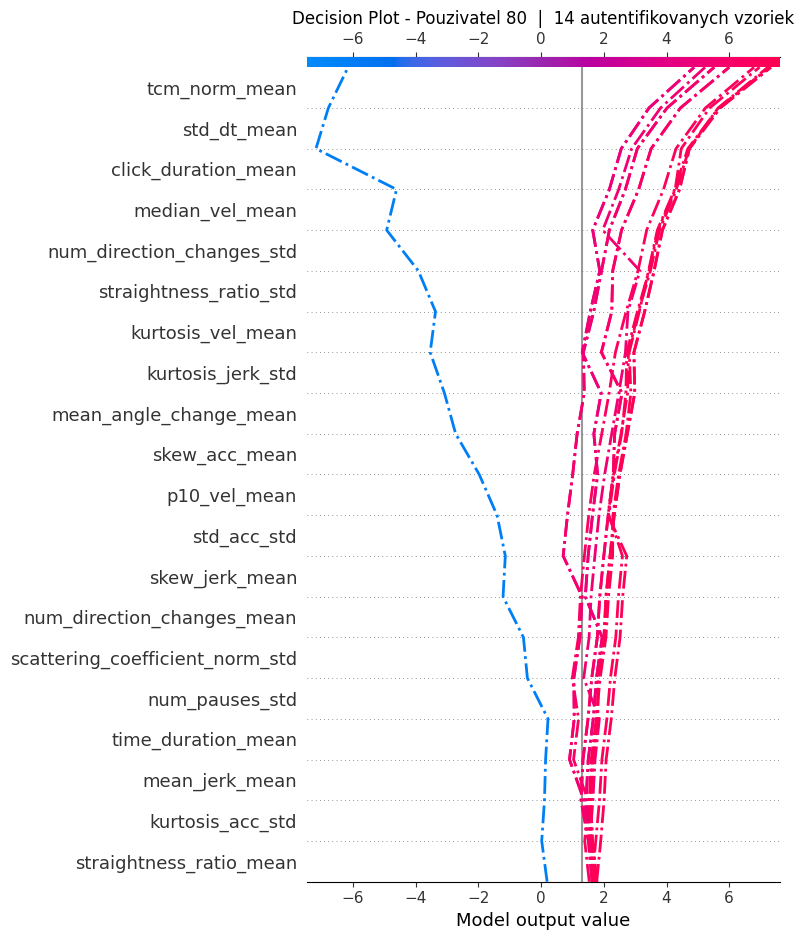

In [20]:
plt.figure(figsize=(12, 8))
shap.decision_plot(
    expected_value,
    shap_values,
    X_test,
    highlight=list(range(len(pos_idx))),
    show=False,
)
plt.title(
    f"Decision Plot - Pouzivatel {USER_ID}  |  {n_pos} autentifikovanych vzoriek",
    fontsize=12,
)
plt.tight_layout()
plt.show()